# Importing all the Important Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the CSV File

In [ ]:
df = pd.read_csv("Housing.csv")

# Exploration

In [ ]:
# Display the first 10 rows
print("First 10 rows:")
df.head(10)

First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
# Check how many rows and columns are there
print(f"\nDataset shape (rows, columns): {df.shape}")


Dataset shape (rows, columns): (545, 13)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
# Check for missing values in each column
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
# Identify Target and Features
print("\nTarget Column: 'price'")
print(f"Feature Columns: {list(df.columns[1:])}")


Target Column: 'price'
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [ ]:
# Handle missing values (dropping any rows with missing data as a safe default)
df = df.dropna()

In [ ]:
# Remove duplicate rows, if any exist
df = df.drop_duplicates()

In [ ]:
# Convert categorical columns into numeric form using one-hot encoding
# drop_first=True prevents the dummy variable trap
df_cleaned = pd.get_dummies(df, drop_first=True, dtype=int)

In [ ]:
# Display the cleaned dataframe to verify meaningful columns are kept
print("Cleaned Data Snapshot:")
display(df_cleaned.head())

Cleaned Data Snapshot:


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [ ]:
df_cleaned.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

# Building the Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Spliting the data into features (X) and target (y)
X = df_cleaned.drop('price', axis=1)
y = df_cleaned['price']

In [ ]:
# Spliting into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# --- 1. Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [ ]:
print("--- Linear Regression Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, lr_preds):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):,.2f}")
print(f"R²:   {r2_score(y_test, lr_preds):.4f}\n")

--- Linear Regression Performance ---
MAE:  970,043.40
RMSE: 1,324,506.96
R²:   0.6529



In [ ]:
# --- 2. Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [ ]:
print("--- Random Forest Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, rf_preds):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):,.2f}")
print(f"R²:   {r2_score(y_test, rf_preds):.4f}")

--- Random Forest Performance ---
MAE:  1,021,546.04
RMSE: 1,400,565.97
R²:   0.6119


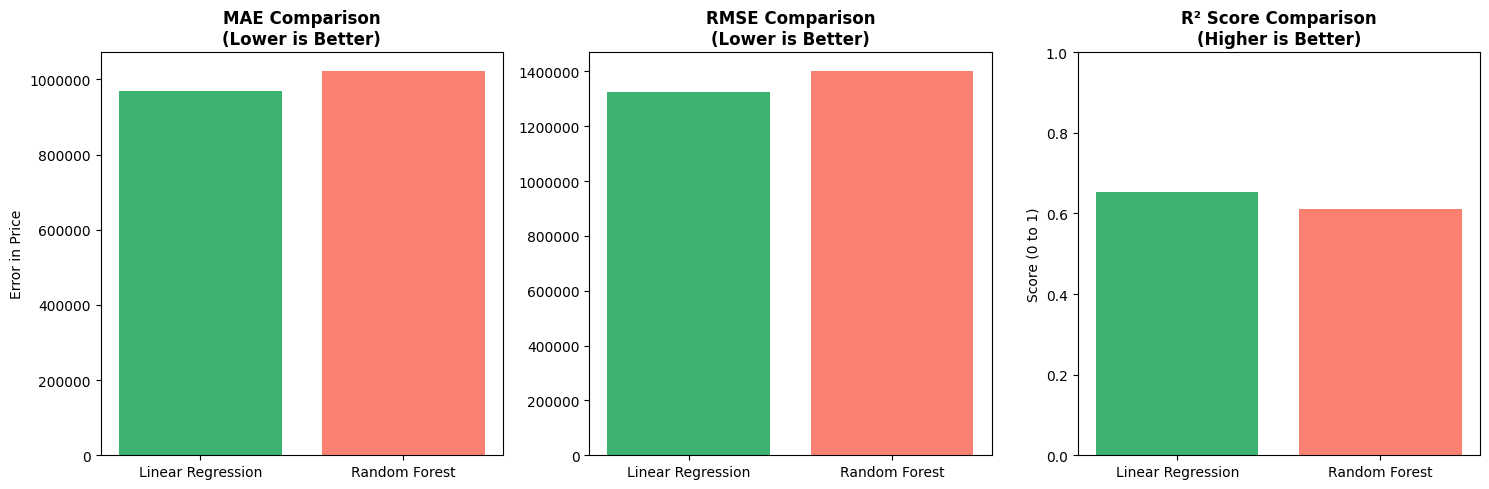

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# calculated metrics
models = ['Linear Regression', 'Random Forest']
mae_scores = [970043.40, 1021546.04]
rmse_scores = [1324506.96, 1400565.97]
r2_scores = [0.6529, 0.6119]

# a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. MAE
axes[0].bar(models, mae_scores, color=['mediumseagreen', 'salmon'])
axes[0].set_title('MAE Comparison\n(Lower is Better)', fontweight='bold')
axes[0].set_ylabel('Error in Price')
# Format y-axis to show millions clearly
axes[0].ticklabel_format(style='plain', axis='y')

# 2. RMSE
axes[1].bar(models, rmse_scores, color=['mediumseagreen', 'salmon'])
axes[1].set_title('RMSE Comparison\n(Lower is Better)', fontweight='bold')
axes[1].ticklabel_format(style='plain', axis='y')

# 3. R²
axes[2].bar(models, r2_scores, color=['mediumseagreen', 'salmon'])
axes[2].set_title('R² Score Comparison\n(Higher is Better)', fontweight='bold')
axes[2].set_ylabel('Score (0 to 1)')
axes[2].set_ylim(0, 1) # Force the y-axis to go from 0 to 1 for R²

# Adjust layout so nothing overlaps and save it
plt.tight_layout()
plt.savefig('charts/model_comparison_final.png')
plt.show()

# Visualization

In [ ]:
import os

os.makedirs('charts', exist_ok=True)

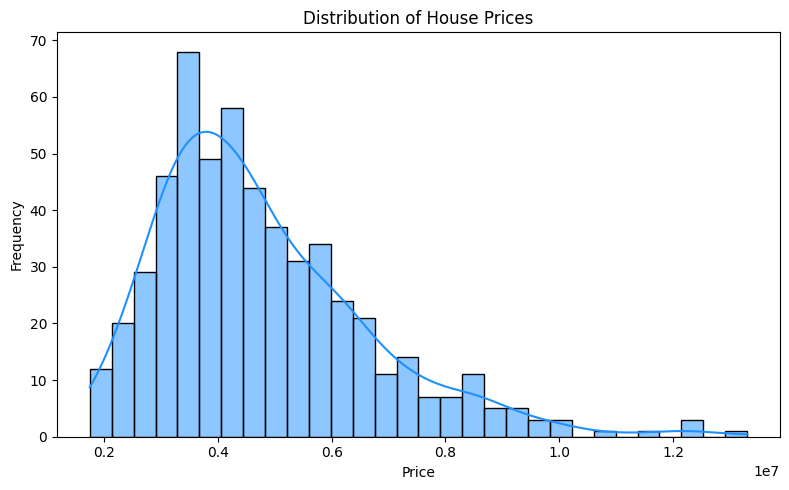

In [ ]:
# Chart 1: Histogram showing the distribution of house prices
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['price'], bins=30, kde=True, color='dodgerblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('charts/price_distribution.png')
plt.show()

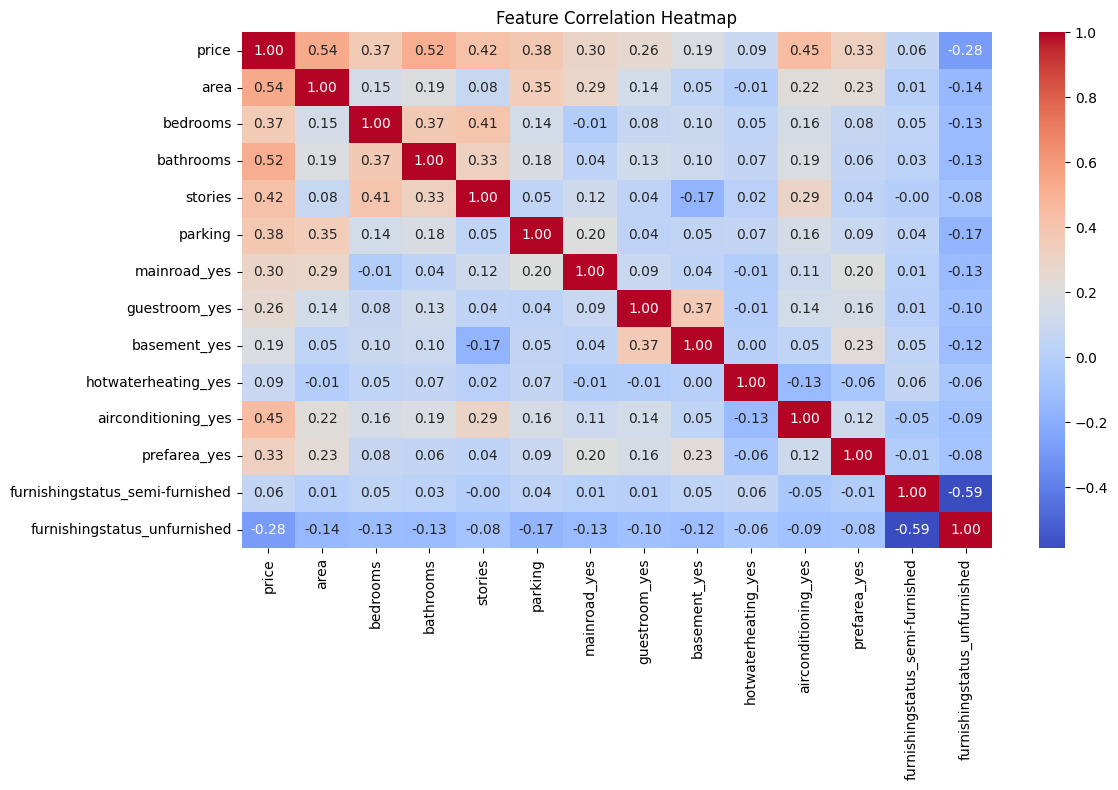

In [ ]:
# Chart 2: Correlation heatmap showing feature relationships
plt.figure(figsize=(12, 8))
correlation_matrix = df_cleaned.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png')
plt.show()

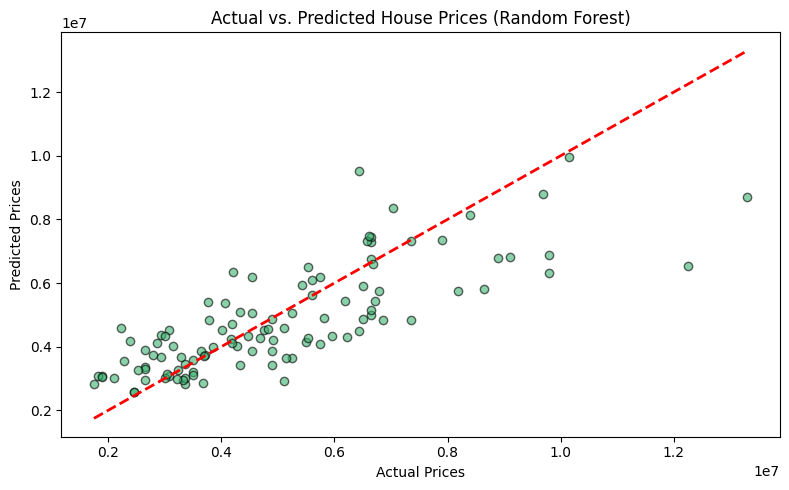

In [ ]:
# Chart 3: Actual vs. Predicted Price Scatter Plot (Random Forest)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_preds, alpha=0.6, color='mediumseagreen', edgecolors='k')
# Plot a perfect prediction line for reference
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted House Prices (Random Forest)')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.tight_layout()
plt.savefig('charts/actual_vs_predicted.png')
plt.show()

/tmp/ipykernel_11408/1349938734.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df_cleaned, palette='Set2')


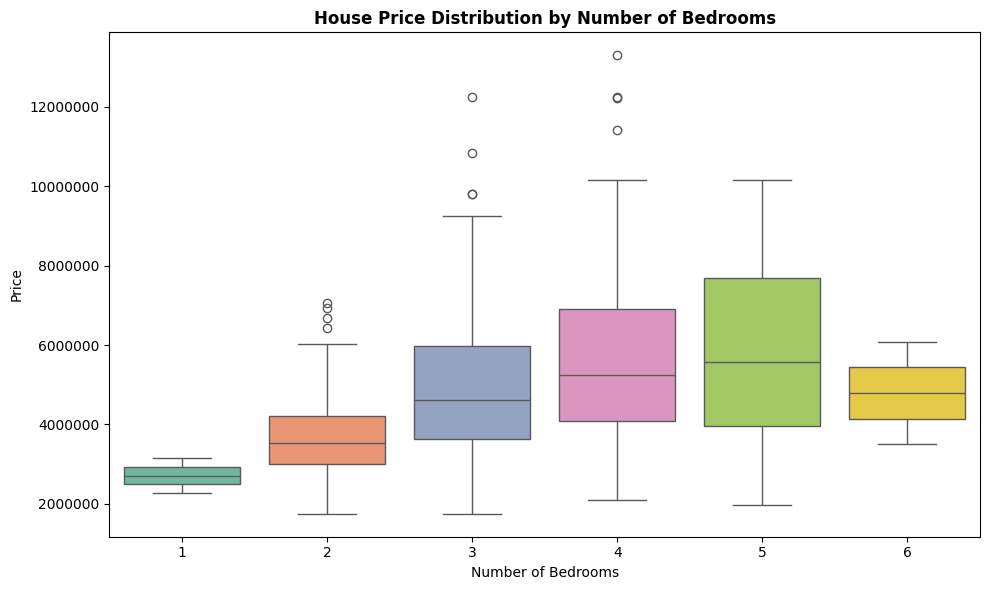

In [ ]:
# 4. Boxplot: Impact of Bedrooms on Price
plt.figure(figsize=(10, 6))

sns.boxplot(x='bedrooms', y='price', data=df_cleaned, palette='Set2')
plt.title('House Price Distribution by Number of Bedrooms', fontweight='bold')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig('charts/price_by_bedrooms.png')
plt.show()

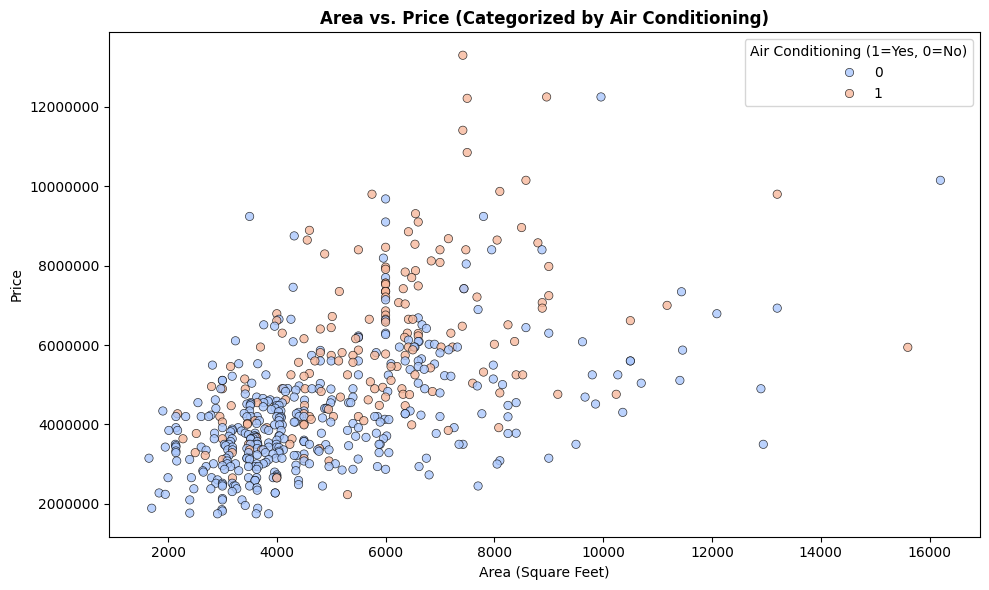

In [ ]:
# 5. Scatterplot: Area vs Price (Colored by Air Conditioning)
plt.figure(figsize=(10, 6))
# Plotting area vs price, using hue to color-code by the AC column
sns.scatterplot(x='area', y='price', hue='airconditioning_yes', data=df_cleaned,
                palette='coolwarm', alpha=0.8, edgecolor='k')
plt.title('Area vs. Price (Categorized by Air Conditioning)', fontweight='bold')
plt.xlabel('Area (Square Feet)')
plt.ylabel('Price')
plt.ticklabel_format(style='plain', axis='y')
# Make the legend easier to read
plt.legend(title='Air Conditioning (1=Yes, 0=No)')
plt.tight_layout()
plt.savefig('charts/area_vs_price_ac.png')
plt.show()

# Insights & Summary

1.  Based on the feature correlation heatmap, a property's total area, number of bathrooms, and the presence of air conditioning influence the final house price the most.

2.  The models were moderately accurate, with the simpler Linear Regression model surprisingly outperforming the Random Forest by successfully explaining about 65% of the variations in housing prices.

3. The most surprising insight from the data was the diminishing return on bedrooms; the boxplot shows that median house prices actually plateau and stop strictly increasing once a house has more than four bedrooms.

4. Therefore, my top recommendation for a real estate business is to base their automated baseline price estimates heavily on raw square footage and core amenities (like AC and bathrooms) rather than just advertising high bedroom counts.